# SuperPoint key-point detector

Synthetic-data training of the MagicPoint detector from the SuperPoint paper, with homographic adaptation for inference on real photos.

**Pipeline:**
1. Generate synthetic images of triangles, quadrilaterals, stars, chessboards, cubes (and mixed) — corner positions are the labels.
2. Train an encoder + 65-channel detector head with cross-entropy loss.
3. At inference time, run the model on the real photo plus 99 random homographic warps; average the warped-back heatmaps; threshold + NMS.


## 0. Imports & device

In [12]:
import os, math, random, glob
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| torch:', torch.__version__)

IMG_W, IMG_H = 320, 240   # both multiples of 8 (= 30 * 40 cells)


device: cuda | torch: 2.5.1+cu121


## 1. Synthetic dataset

### 1.1 Color & noise helpers

In [13]:
def random_color(minv=30, maxv=225):
    return np.random.randint(minv, maxv + 1, 3).tolist()

def ensure_contrast(bg, fg, thr=40):
    while abs(np.mean(bg) - np.mean(fg)) < thr:
        fg = random_color()
    return fg

def add_smoothed_noise(img, sigma=10):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    img = np.clip(img + noise, 0, 255).astype(np.uint8)
    return cv2.GaussianBlur(img, (3, 3), 0)

def far_enough(pt, pts, d):
    return all((pt[0] - x) ** 2 + (pt[1] - y) ** 2 >= d * d for x, y in pts)


### 1.2 Simple shapes — triangle, quadrilateral, star

In [14]:
def random_triangle(W, H, d=20):
    pts = []
    while len(pts) < 3:
        x = np.random.randint(5, W - 5)
        y = np.random.randint(5, H - 5)
        if far_enough([x, y], pts, d):
            pts.append([x, y])
    return pts

def random_quadrilateral(W, H, jitter=25):
    """Axis-aligned rectangle + per-corner jitter — always convex, never self-intersects."""
    x1 = np.random.randint(40, max(41, W - 120))
    y1 = np.random.randint(40, max(41, H - 120))
    w = np.random.randint(40, 120)
    h = np.random.randint(40, 120)
    corners = np.array([[x1, y1], [x1 + w, y1], [x1 + w, y1 + h], [x1, y1 + h]], np.float32)
    corners += np.random.randint(-jitter, jitter + 1, corners.shape)
    corners[:, 0] = np.clip(corners[:, 0], 5, W - 5)
    corners[:, 1] = np.clip(corners[:, 1], 5, H - 5)
    return corners.tolist()

def random_star(W, H, center_r=80, d=20):
    cx = np.random.randint(center_r, W - center_r)
    cy = np.random.randint(center_r, H - center_r)
    pts = [[cx, cy]]
    while len(pts) < 6:
        ox = int(np.clip(cx + np.random.randint(-center_r, center_r), 5, W - 5))
        oy = int(np.clip(cy + np.random.randint(-center_r, center_r), 5, H - 5))
        if far_enough([ox, oy], pts, d):
            pts.append([ox, oy])
    return pts

def draw_triangle(img, pts, color):
    cv2.fillPoly(img, [np.array(pts, np.int32)], color)

def draw_quadrilateral(img, pts, color):
    cv2.fillPoly(img, [np.array(pts, np.int32)], color)

def draw_star(img, pts, color):
    C = pts[0]
    for p in pts[1:]:
        cv2.line(img, tuple(map(int, C)), tuple(map(int, p)), color, 3)


### 1.3 Complex shapes — chessboard, 3D cube

In [15]:
def random_chessboard(W, H, rows=3, cols=4):
    margin = 20
    cb_w = np.random.randint(100, max(101, min(200, W - 2 * margin)))
    cb_h = np.random.randint(100, max(101, min(200, H - 2 * margin)))
    x0 = np.random.randint(margin, max(margin + 1, W - margin - cb_w))
    y0 = np.random.randint(margin, max(margin + 1, H - margin - cb_h))
    cell_w = cb_w // cols
    cell_h = cb_h // rows
    keypoints = [[x0 + c * cell_w, y0 + r * cell_h]
                 for r in range(rows + 1) for c in range(cols + 1)]
    return keypoints, (x0, y0, cb_w, cb_h)

def draw_chessboard(img, x0, y0, cb_w, cb_h, rows=3, cols=4):
    cell_w = cb_w // cols
    cell_h = cb_h // rows
    c1 = random_color()
    c2 = ensure_contrast(c1, random_color())
    for r in range(rows):
        for c in range(cols):
            col = c1 if (r + c) % 2 == 0 else c2
            x1 = x0 + c * cell_w
            y1 = y0 + r * cell_h
            cv2.rectangle(img, (x1, y1), (x1 + cell_w, y1 + cell_h), col, -1)

def random_cube(W, H):
    cx = np.random.randint(60, W - 60)
    cy = np.random.randint(60, H - 60)
    C = [cx, cy]
    base_angle = np.random.uniform(0, 2 * np.pi)
    inner = []
    for k in range(3):
        a = base_angle + k * 2 * np.pi / 3
        d = np.random.randint(30, 80)
        inner.append([
            int(np.clip(cx + d * np.cos(a), 5, W - 5)),
            int(np.clip(cy + d * np.sin(a), 5, H - 5)),
        ])
    I1, I2, I3 = inner

    def outer(A, B):
        mx, my = (A[0] + B[0]) / 2, (A[1] + B[1]) / 2
        dx, dy = mx - cx, my - cy
        scale = np.random.uniform(1.2, 1.8)
        return [
            int(np.clip(cx + dx * scale, 5, W - 5)),
            int(np.clip(cy + dy * scale, 5, H - 5)),
        ]

    O12 = outer(I1, I2)
    O23 = outer(I2, I3)
    O31 = outer(I3, I1)
    return [C, I1, I2, I3, O12, O23, O31]

def draw_cube(img, pts):
    C, I1, I2, I3, O12, O23, O31 = pts
    faces = [[C, I1, O12, I2], [C, I2, O23, I3], [C, I3, O31, I1]]
    cols = [random_color() for _ in faces]
    for face, col in zip(faces, cols):
        arr = np.array(face, np.int32)
        cv2.fillPoly(img, [arr], col)
        cv2.polylines(img, [arr], True, (0, 0, 0), 2)


### 1.4 Single-shape and multi-shape image generators

In [16]:
def generate_simple_shape(shape, W, H):
    bg = random_color()
    img = np.full((H, W, 3), bg, np.uint8)
    fg = ensure_contrast(bg, random_color())

    if shape == 'triangle':
        kps = random_triangle(W, H)
        draw_triangle(img, kps, fg)
    elif shape == 'quadrilateral':
        kps = random_quadrilateral(W, H)
        draw_quadrilateral(img, kps, fg)
    elif shape == 'star':
        kps = random_star(W, H)
        draw_star(img, kps, fg)
    elif shape == 'chessboard':
        kps, box = random_chessboard(W, H)
        draw_chessboard(img, *box)
    elif shape == 'cube':
        kps = random_cube(W, H)
        draw_cube(img, kps)
    else:
        raise ValueError(shape)

    return add_smoothed_noise(img), kps


def generate_multiple_shapes(W, H, max_shapes=4):
    bg = random_color()
    img = np.full((H, W, 3), bg, np.uint8)
    mask = np.zeros((H, W), np.uint8)
    all_kps = []
    types = ['triangle', 'quadrilateral', 'star']

    attempts = 0
    while len(all_kps) < max_shapes * 6 and attempts < 80:
        attempts += 1
        st = np.random.choice(types)
        if st == 'triangle':
            pts = random_triangle(W, H)
        elif st == 'quadrilateral':
            pts = random_quadrilateral(W, H)
        else:
            pts = random_star(W, H)

        tmp = np.zeros_like(mask)
        if st == 'star':
            C = pts[0]
            for p in pts[1:]:
                cv2.line(tmp, tuple(map(int, C)), tuple(map(int, p)), 255, 3)
        else:
            cv2.fillPoly(tmp, [np.array(pts, np.int32)], 255)

        if np.any(mask & tmp):
            continue

        col = ensure_contrast(bg, random_color())
        if st == 'triangle':
            draw_triangle(img, pts, col)
        elif st == 'quadrilateral':
            draw_quadrilateral(img, pts, col)
        else:
            draw_star(img, pts, col)

        mask |= tmp
        all_kps.extend(pts)

    return add_smoothed_noise(img), all_kps


### 1.5 Homography augmentation

In [17]:
def random_homography(W, H, min_dist=80):
    cx, cy = W // 2, H // 2

    def rp(xmin, xmax, ymin, ymax):
        while True:
            x = np.random.randint(xmin, xmax)
            y = np.random.randint(ymin, ymax)
            if (x - cx) ** 2 + (y - cy) ** 2 >= min_dist * min_dist:
                return [x, y]

    src = np.array([
        rp(0, cx, 0, cy), rp(cx, W, 0, cy),
        rp(cx, W, cy, H), rp(0, cx, cy, H),
    ], np.float32)
    dst = np.array([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]], np.float32)
    return cv2.getPerspectiveTransform(src, dst)


def maybe_add_rotation(Hm, W, H):
    k = np.random.randint(0, 4)
    if k == 0:
        return Hm
    M = cv2.getRotationMatrix2D((W / 2, H / 2), 90 * k, 1.0)
    R = np.vstack([M, [0, 0, 1]]).astype(np.float32)
    return R @ Hm


def apply_homography(img, kps, Hm, W, H):
    warped = cv2.warpPerspective(img, Hm, (W, H))
    if not kps:
        return warped, []
    pts = np.array(kps, np.float32)
    pts_h = np.hstack([pts, np.ones((len(pts), 1), np.float32)])
    out = (Hm @ pts_h.T).T
    xs = out[:, 0] / out[:, 2]
    ys = out[:, 1] / out[:, 2]
    return warped, [[int(x), int(y)] for x, y in zip(xs, ys) if 0 <= x < W and 0 <= y < H]


def augment_with_homography(img, kps, W, H):
    Hm = random_homography(W, H)
    Hm = maybe_add_rotation(Hm, W, H)
    return apply_homography(img, kps, Hm, W, H)


### 1.6 Visualize sample synthetic images (for the report)

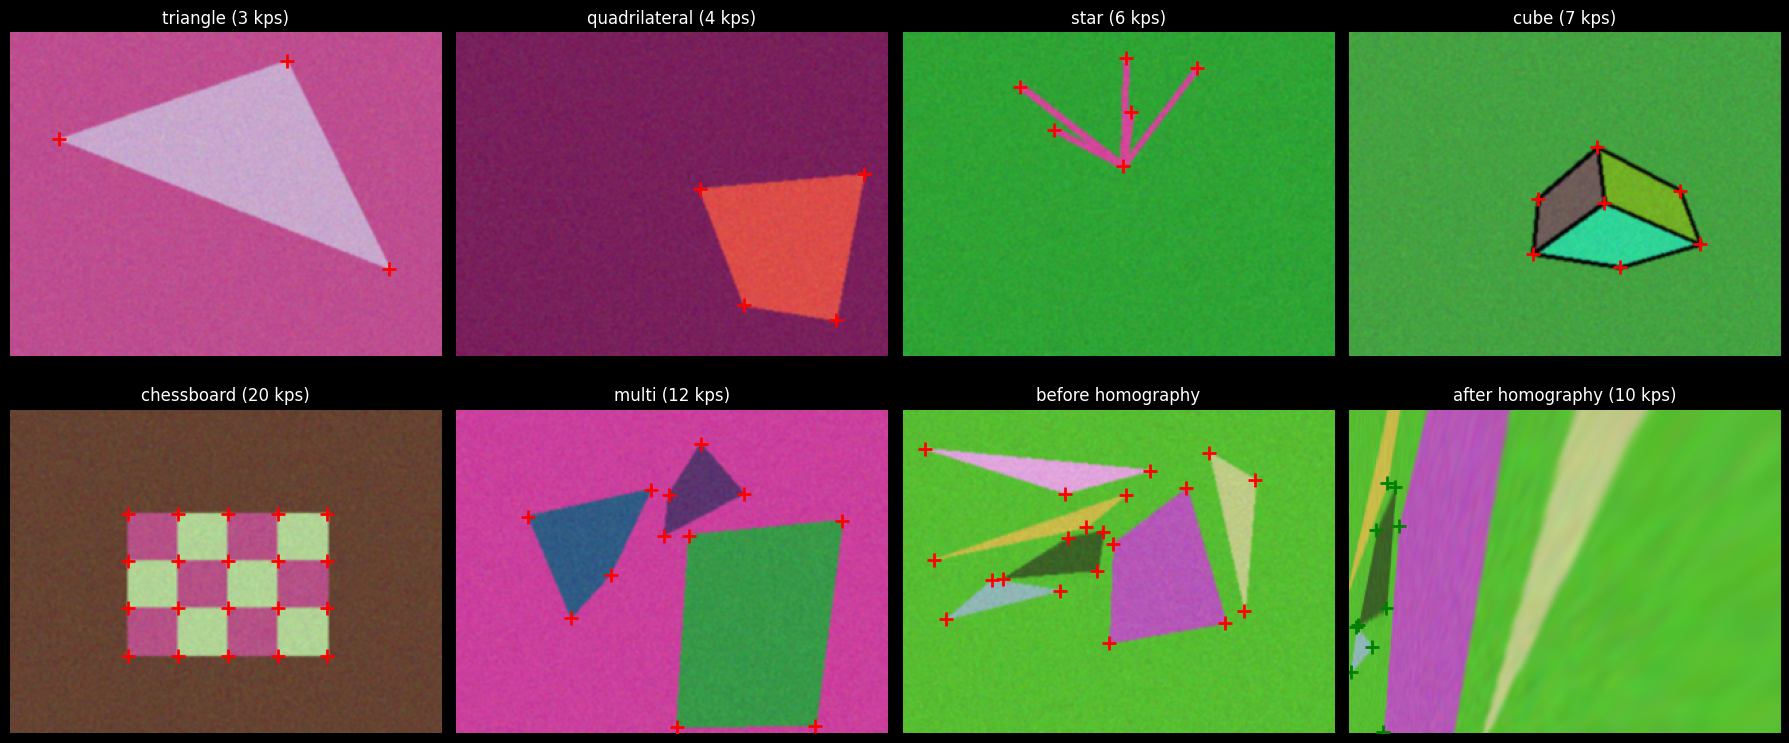

In [18]:
def show_sample_grid():
    fig, axs = plt.subplots(2, 4, figsize=(18, 8))

    for ax, s in zip(axs[0], ['triangle', 'quadrilateral', 'star', 'cube']):
        img, kps = generate_simple_shape(s, IMG_W, IMG_H)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        for x, y in kps:
            ax.plot(x, y, 'r+', ms=10, mew=2)
        ax.set_title(f'{s} ({len(kps)} kps)')
        ax.axis('off')

    img, kps = generate_simple_shape('chessboard', IMG_W, IMG_H)
    axs[1, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 0].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 0].set_title(f'chessboard ({len(kps)} kps)')
    axs[1, 0].axis('off')

    img, kps = generate_multiple_shapes(IMG_W, IMG_H)
    axs[1, 1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 1].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 1].set_title(f'multi ({len(kps)} kps)')
    axs[1, 1].axis('off')

    img, kps = generate_multiple_shapes(IMG_W, IMG_H)
    img2, kps2 = augment_with_homography(img, kps, IMG_W, IMG_H)
    axs[1, 2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 2].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 2].set_title('before homography')
    axs[1, 2].axis('off')

    axs[1, 3].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    for x, y in kps2:
        axs[1, 3].plot(x, y, 'g+', ms=10, mew=2)
    axs[1, 3].set_title(f'after homography ({len(kps2)} kps)')
    axs[1, 3].axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid()


## 2. Neural network — encoder + detector head

In [19]:
class ResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.proj is not None:
            identity = self.proj(identity)
        return F.relu(out + identity)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            ResNetBlock(1, 64),     ResNetBlock(64, 64),     nn.MaxPool2d(2),
            ResNetBlock(64, 64),    ResNetBlock(64, 64),     nn.MaxPool2d(2),
            ResNetBlock(64, 128),   ResNetBlock(128, 128),   nn.MaxPool2d(2),
            ResNetBlock(128, 128),  ResNetBlock(128, 128),
        )
    def forward(self, x):
        return self.body(x)


class DetectorHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(128, 256, 3, padding=1)
        self.bn = nn.BatchNorm2d(256)
        self.out = nn.Conv2d(256, 65, 1)

    def forward(self, x):
        return self.out(F.relu(self.bn(self.conv(x))))


class SuperPointDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.head = DetectorHead()

    def forward(self, x):
        return self.head(self.encoder(x))    # logits  [B, 65, H/8, W/8]


# Quick shape sanity check
_m = SuperPointDetector().to(device)
_y = _m(torch.randn(2, 1, IMG_H, IMG_W, device=device))
print('logits:', _y.shape, '(expect [2, 65, %d, %d])' % (IMG_H // 8, IMG_W // 8))
del _m, _y


logits: torch.Size([2, 65, 30, 40]) (expect [2, 65, 30, 40])


## 3. Training

### 3.1 Mask → 65-class grid + Dataset

In [20]:
def keypoints_to_grid(mask):
    """mask: HxW (0/1) → grid: Hc x Wc x 65 one-hot (channel 64 = dustbin)."""
    H, W = mask.shape
    Hc, Wc = H // 8, W // 8
    m = mask.reshape(Hc, 8, Wc, 8)
    m = np.transpose(m, (0, 2, 1, 3))
    m = m.reshape(Hc, Wc, 64)
    grid = np.zeros((Hc, Wc, 65), dtype=np.float32)
    grid[..., 64] = 1.0
    for i in range(Hc):
        for j in range(Wc):
            idxs = np.where(m[i, j] > 0)[0]
            if len(idxs) > 0:
                keep = np.random.choice(idxs)
                grid[i, j, :] = 0
                grid[i, j, keep] = 1.0
    return grid


class SyntheticDataset(Dataset):
    def __init__(self, W=IMG_W, H=IMG_H, h_prob=0.7):
        self.W, self.H = W, H
        self.h_prob = h_prob

    def __len__(self):
        return 9_999_999

    def __getitem__(self, idx):
        mode = np.random.choice(['simple', 'complex', 'multi'], p=[0.4, 0.4, 0.2])
        if mode == 'simple':
            shape = np.random.choice(['triangle', 'quadrilateral', 'star'])
            img, kps = generate_simple_shape(shape, self.W, self.H)
        elif mode == 'complex':
            shape = np.random.choice(['chessboard', 'cube'])
            img, kps = generate_simple_shape(shape, self.W, self.H)
        else:
            img, kps = generate_multiple_shapes(self.W, self.H, max_shapes=4)

        if np.random.rand() < self.h_prob:
            img, kps = augment_with_homography(img, kps, self.W, self.H)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        mask = np.zeros((self.H, self.W), dtype=np.float32)
        for x, y in kps:
            if 0 <= x < self.W and 0 <= y < self.H:
                mask[int(y), int(x)] = 1.0

        grid = keypoints_to_grid(mask)
        img_t = torch.from_numpy(gray).unsqueeze(0)
        grid_t = torch.from_numpy(grid).permute(2, 0, 1).float()
        return img_t, grid_t


### 3.2 Loss

In [21]:
def loss_fn(logits, target):
    """logits: [B, 65, Hc, Wc]   target: [B, 65, Hc, Wc] one-hot"""
    idx = torch.argmax(target, dim=1)        # [B, Hc, Wc]
    return F.cross_entropy(logits, idx)


### 3.3 Training loop (5000 iterations, save best-loss checkpoint)

Best-loss checkpointing is the key trick: the network can saturate quickly on synthetic data, so the checkpoint with the lowest validation-style loss tends to generalize better to real photos than the last-iteration checkpoint.

In [22]:
MAX_ITERS = 5000
BATCH_SIZE = 8
PRINT_EVERY = 100

dataset = SyntheticDataset(IMG_W, IMG_H, h_prob=0.7)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, drop_last=True)

model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

loss_history = []
best_loss = float('inf')
iteration = 0
model.train()

while iteration < MAX_ITERS:
    for img, target in loader:
        img = img.to(device); target = target.to(device)
        optimizer.zero_grad()
        logits = model(img)
        loss = loss_fn(logits, target)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if iteration % PRINT_EVERY == 0:
            print(f'[{iteration:5d}] loss={loss.item():.4f}  best={best_loss:.4f}')

        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save({'model_state_dict': model.state_dict(),
                        'iteration': iteration,
                        'loss': best_loss}, 'model_best.pth')

        iteration += 1
        if iteration >= MAX_ITERS:
            break

torch.save({'model_state_dict': model.state_dict(),
            'iteration': iteration,
            'loss_history': loss_history}, 'model_final.pth')

print(f'\ndone. best loss = {best_loss:.4f}')


[    0] loss=4.1366  best=inf
[  100] loss=0.0585  best=0.0315
[  200] loss=0.0525  best=0.0299
[  300] loss=0.0435  best=0.0255
[  400] loss=0.0394  best=0.0196
[  500] loss=0.0386  best=0.0196
[  600] loss=0.0331  best=0.0114
[  700] loss=0.0303  best=0.0114
[  800] loss=0.0327  best=0.0114
[  900] loss=0.0221  best=0.0114
[ 1000] loss=0.0203  best=0.0087
[ 1100] loss=0.0272  best=0.0087
[ 1200] loss=0.0188  best=0.0087
[ 1300] loss=0.0188  best=0.0087
[ 1400] loss=0.0330  best=0.0087
[ 1500] loss=0.0223  best=0.0087
[ 1600] loss=0.0162  best=0.0079
[ 1700] loss=0.0180  best=0.0079
[ 1800] loss=0.0228  best=0.0079
[ 1900] loss=0.0185  best=0.0062
[ 2000] loss=0.0324  best=0.0062
[ 2100] loss=0.0201  best=0.0062
[ 2200] loss=0.0180  best=0.0062
[ 2300] loss=0.0243  best=0.0062
[ 2400] loss=0.0106  best=0.0058
[ 2500] loss=0.0128  best=0.0058
[ 2600] loss=0.0287  best=0.0058
[ 2700] loss=0.0168  best=0.0058
[ 2800] loss=0.0200  best=0.0058
[ 2900] loss=0.0112  best=0.0058
[ 3000] loss=

### 3.4 Loss curve

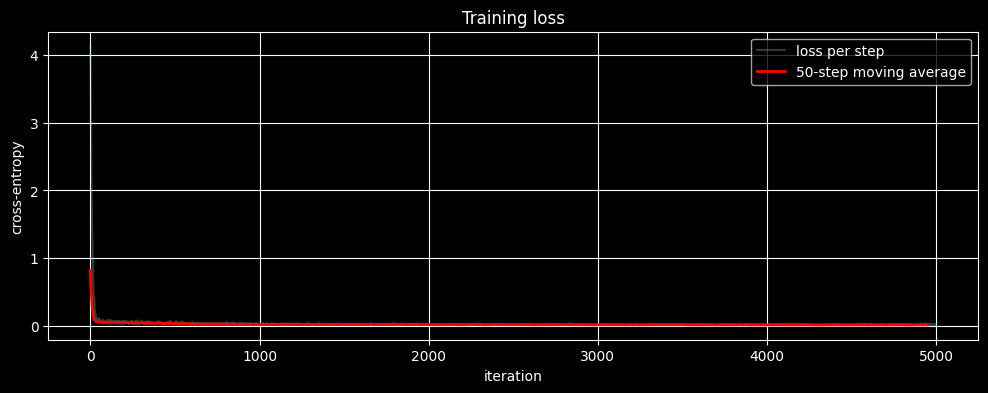

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(loss_history, alpha=0.3, label='loss per step')
if len(loss_history) > 50:
    smooth = np.convolve(loss_history, np.ones(50) / 50, mode='valid')
    plt.plot(smooth, color='red', linewidth=2, label='50-step moving average')
plt.title('Training loss')
plt.xlabel('iteration'); plt.ylabel('cross-entropy')
plt.grid(); plt.legend()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Inference utilities

In [24]:
def decode_to_prob_map(logits):
    """logits [B, 65, Hc, Wc] → prob_map [B, 1, H, W]."""
    B, C, Hc, Wc = logits.shape
    probs = F.softmax(logits, dim=1)[:, :-1]            # drop dustbin → [B, 64, Hc, Wc]
    probs = probs.view(B, 8, 8, Hc, Wc)
    probs = probs.permute(0, 3, 1, 4, 2)                # [B, Hc, 8, Wc, 8]
    return probs.reshape(B, 1, Hc * 8, Wc * 8)


def get_predicted_keypoints(prob_map, percentile=99.5, nms_radius=4, max_kp=500):
    """Percentile threshold + non-maxima suppression."""
    prob = prob_map[0, 0].cpu().numpy()
    thr = float(np.percentile(prob, percentile))
    mask = prob > thr
    if mask.sum() == 0:
        return [], prob
    k = 2 * nms_radius + 1
    local_max = (prob == cv2.dilate(prob, np.ones((k, k), np.uint8)))
    keep = mask & local_max
    ys, xs = np.where(keep)
    if len(xs) == 0:
        return [], prob
    scores = prob[ys, xs]
    order = np.argsort(-scores)[:max_kp]
    return [(int(xs[i]), int(ys[i])) for i in order], prob


def load_best_model(path='model_best.pth'):
    ckpt = torch.load(path, map_location=device)
    m = SuperPointDetector().to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f'loaded best model from {path}  (iter={ckpt.get("iteration")} loss={ckpt.get("loss"):.4f})')
    return m


best_model = load_best_model()


loaded best model from model_best.pth  (iter=3712 loss=0.0039)


C:\Users\Andrea Korunoska\AppData\Local\Temp\ipykernel_45000\2685242945.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


## 5. Predictions on synthetic samples (sanity check)

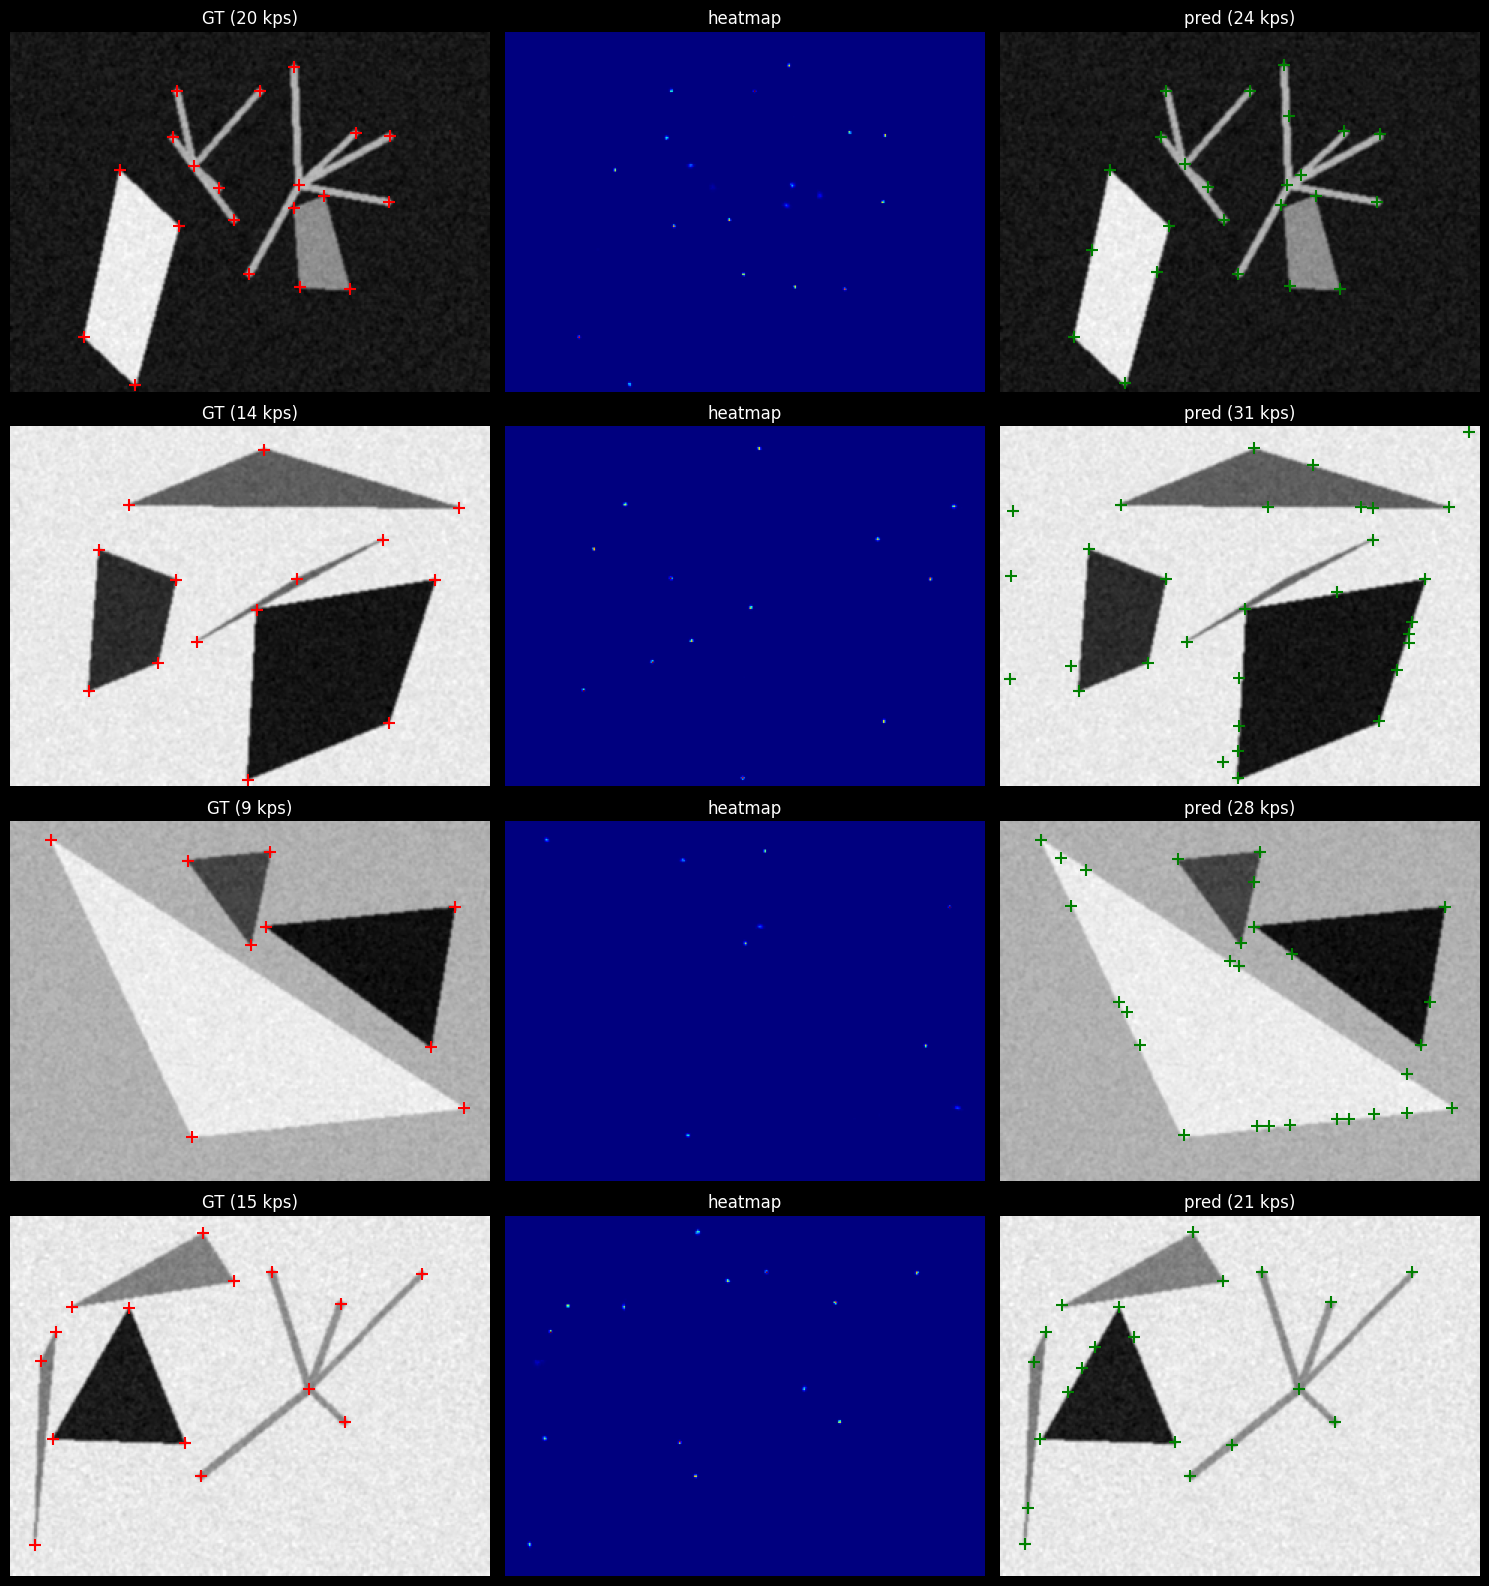

In [25]:
def show_synthetic_predictions(model, n=4):
    fig, axs = plt.subplots(n, 3, figsize=(15, 4 * n))
    for r in range(n):
        img, kps = generate_multiple_shapes(IMG_W, IMG_H, max_shapes=4)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x)
            prob_map = decode_to_prob_map(logits)
        pred, prob = get_predicted_keypoints(prob_map, percentile=99.5)

        axs[r, 0].imshow(gray, cmap='gray')
        for x_, y_ in kps: axs[r, 0].plot(x_, y_, 'r+', ms=8, mew=1.5)
        axs[r, 0].set_title(f'GT ({len(kps)} kps)'); axs[r, 0].axis('off')

        axs[r, 1].imshow(prob, cmap='jet')
        axs[r, 1].set_title('heatmap'); axs[r, 1].axis('off')

        axs[r, 2].imshow(gray, cmap='gray')
        for x_, y_ in pred: axs[r, 2].plot(x_, y_, 'g+', ms=8, mew=1.5)
        axs[r, 2].set_title(f'pred ({len(pred)} kps)'); axs[r, 2].axis('off')

    plt.tight_layout(); plt.show()


show_synthetic_predictions(best_model, n=4)


## 6. Homographic adaptation

Run the model on the input plus N random homographic warps, warp each output back, average them, and threshold the mean. Each pixel is averaged only over warps that actually saw it (border tracking via a mask).

In [26]:
def homographic_adaptation(model, gray01, num_h=99, include_identity=True):
    H, W = gray01.shape
    acc = np.zeros((H, W), dtype=np.float32)
    cnt = np.zeros((H, W), dtype=np.float32)
    ones = np.ones((H, W), dtype=np.float32)

    def forward(g):
        x = torch.from_numpy(g).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x)
            prob_map = decode_to_prob_map(logits)
        return prob_map[0, 0].cpu().numpy().astype(np.float32)

    if include_identity:
        acc += forward(gray01)
        cnt += ones

    for _ in range(num_h):
        Hm = random_homography(W, H)
        Hm = maybe_add_rotation(Hm, W, H).astype(np.float32)
        if abs(np.linalg.det(Hm)) < 1e-8:
            continue
        Hinv = np.linalg.inv(Hm).astype(np.float32)
        warped = cv2.warpPerspective(gray01, Hm, (W, H),
                                     flags=cv2.INTER_LINEAR,
                                     borderMode=cv2.BORDER_REFLECT_101).astype(np.float32)
        p_warp = forward(warped)
        p_back = cv2.warpPerspective(p_warp, Hinv, (W, H),
                                     flags=cv2.INTER_LINEAR,
                                     borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)
        m_back = cv2.warpPerspective(ones, Hinv, (W, H),
                                     flags=cv2.INTER_NEAREST,
                                     borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)
        acc += p_back
        cnt += m_back

    return acc / np.maximum(cnt, 1e-6)


def kps_from_prob(prob, percentile=99.5, nms_radius=4, max_kp=500):
    H, W = prob.shape
    thr = float(np.percentile(prob, percentile))
    mask = prob > thr
    if mask.sum() == 0:
        return []
    k = 2 * nms_radius + 1
    lm = (prob == cv2.dilate(prob, np.ones((k, k), np.uint8)))
    ys, xs = np.where(mask & lm)
    if len(xs) == 0:
        return []
    scores = prob[ys, xs]
    order = np.argsort(-scores)[:max_kp]
    return [(int(xs[i]), int(ys[i])) for i in order]


## 7. Demo on a real photo

Reads `real_photo.jpg` from this folder, resizes to the training resolution (320×240), runs both single-pass and homographic adaptation, and shows them side-by-side.

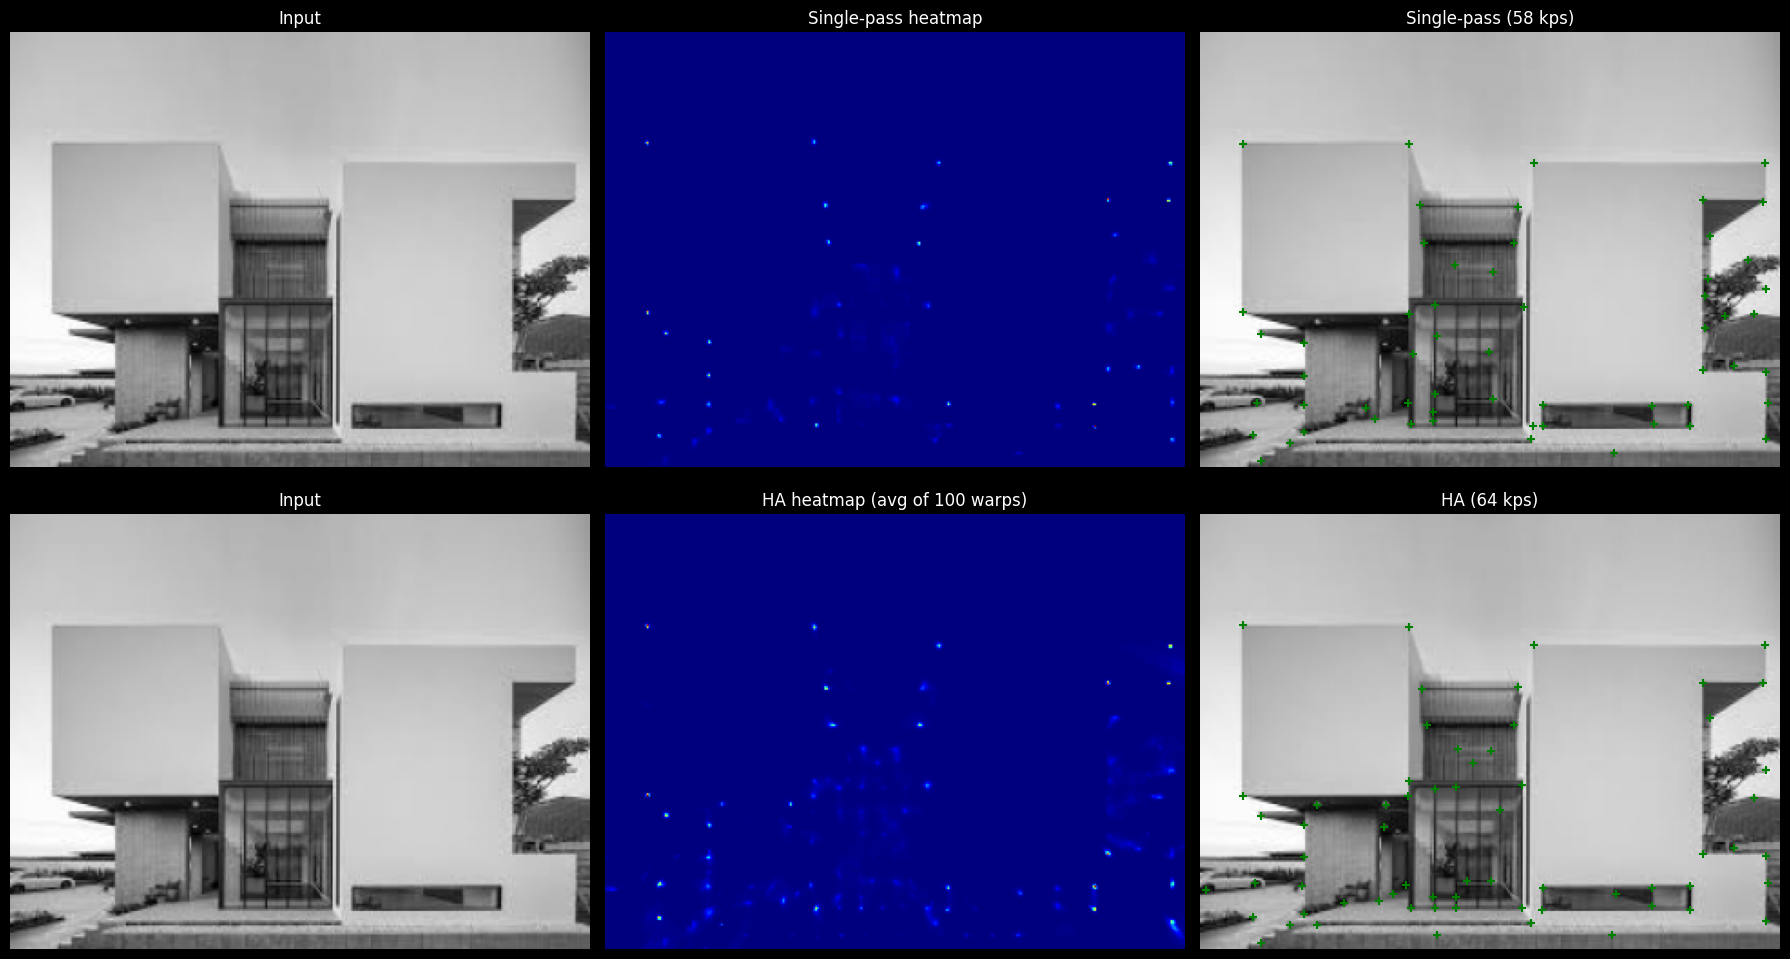

In [27]:
PHOTO_PATH = 'real_photo.jpg'

def predict_on_photo(path, model, W=IMG_W, H=IMG_H, num_h=99, percentile=99.5):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.resize(img, (W, H), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # single forward pass
    x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        prob_single = decode_to_prob_map(logits)[0, 0].cpu().numpy()

    # homographic adaptation
    prob_ha = homographic_adaptation(model, gray, num_h=num_h)

    kps_single = kps_from_prob(prob_single, percentile=percentile)
    kps_ha = kps_from_prob(prob_ha, percentile=percentile)

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs[0, 0].imshow(gray, cmap='gray'); axs[0, 0].set_title('Input'); axs[0, 0].axis('off')
    axs[0, 1].imshow(prob_single, cmap='jet'); axs[0, 1].set_title('Single-pass heatmap'); axs[0, 1].axis('off')
    axs[0, 2].imshow(gray, cmap='gray')
    for x_, y_ in kps_single: axs[0, 2].plot(x_, y_, 'g+', ms=6, mew=1.5)
    axs[0, 2].set_title(f'Single-pass ({len(kps_single)} kps)'); axs[0, 2].axis('off')

    axs[1, 0].imshow(gray, cmap='gray'); axs[1, 0].set_title('Input'); axs[1, 0].axis('off')
    axs[1, 1].imshow(prob_ha, cmap='jet')
    axs[1, 1].set_title(f'HA heatmap (avg of {num_h + 1} warps)'); axs[1, 1].axis('off')
    axs[1, 2].imshow(gray, cmap='gray')
    for x_, y_ in kps_ha: axs[1, 2].plot(x_, y_, 'g+', ms=6, mew=1.5)
    axs[1, 2].set_title(f'HA ({len(kps_ha)} kps)'); axs[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig('real_photo_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()
    return kps_single, kps_ha, prob_single, prob_ha


kps_single, kps_ha, prob_single, prob_ha = predict_on_photo(
    PHOTO_PATH, best_model, num_h=99, percentile=99.5)
